# Fashion MNIST Data, Heterogeneity in FL

### Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import random
import copy
import time
from functools import reduce
from torchsummary import summary
import matplotlib.pyplot as plt
import csv

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [3]:
import math
import torch
from torch.optim import Optimizer


class SGD(Optimizer):
    
    def __init__(self, params, lr, momentum=0, dampening=0,
                 weight_decay=0, nesterov=False):
        if lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if momentum < 0.0:
            raise ValueError("Invalid momentum value: {}".format(momentum))
        if weight_decay < 0.0:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr=lr, momentum=momentum, dampening=dampening,
                        weight_decay=weight_decay, nesterov=nesterov)
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(SGD, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(SGD, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    def step(self, grads, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            weight_decay = group['weight_decay']
            momentum = group['momentum']
            dampening = group['dampening']
            nesterov = group['nesterov']

            for i,p in enumerate(group['params']):
#                 if p.grad is None:
#                     continue
                
                d_p = grads[i]
                
                if weight_decay != 0:
                    d_p.add_(weight_decay, p.data)
                if momentum != 0:
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        buf = param_state['momentum_buffer'] = torch.clone(d_p).detach()
                    else:
                        buf = param_state['momentum_buffer']
                        buf.mul_(momentum).add_(1 - dampening, d_p)
                    if nesterov:
                        d_p = d_p.add(momentum, buf)
                    else:
                        d_p = buf

                p.data.add_(-group['lr'], d_p)

        return loss

In [4]:
class cnn(nn.Module):
    def __init__(self):
        super(cnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 30, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(30, 50, 5)
        self.pool2 = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(800, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
criterion = nn.CrossEntropyLoss()

### Load dataset

In [7]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_data = torch.utils.data.DataLoader(trainset, batch_size=60000, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_data = torch.utils.data.DataLoader(testset, batch_size=5000, shuffle=False)

### Adjustable parameters

# ===============================
# bias = 0.1, # of clients = 15
# ===============================

In [8]:
bias = 0.1
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

### Distributing data, changes when bias changes

In [9]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_170884/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [10]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [11]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [12]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

In [13]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(gain)

### Main Code

In [14]:
accuracy_bias_0_1 = []

In [15]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1.append(correct/total)

/tmp/ipykernel_170884/1472790098.py:64: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1642.)
  p.data.add_(-group['lr'], d_p)


0 0.1692
1 0.158
2 0.19
3 0.2481
4 0.2931
5 0.3311
6 0.3586
7 0.3785
8 0.3999
9 0.4189
10 0.4364
11 0.4483
12 0.4591
13 0.4673
14 0.475
15 0.4805
16 0.4841
17 0.4892
18 0.4932
19 0.4979
20 0.5042
21 0.5096
22 0.5149
23 0.5228
24 0.5282
25 0.5337
26 0.5393
27 0.5435
28 0.5458
29 0.548
30 0.5488
31 0.5517
32 0.5531
33 0.5559
34 0.5591
35 0.5608
36 0.5627
37 0.5651
38 0.5684
39 0.5718
40 0.5766
41 0.5815
42 0.585
43 0.5893
44 0.5939
45 0.5981
46 0.6021
47 0.6066
48 0.611
49 0.6144
50 0.6176
51 0.6213
52 0.6249
53 0.6272
54 0.6302
55 0.6333
56 0.635
57 0.6371
58 0.6393
59 0.6407
60 0.6431
61 0.6453
62 0.6472
63 0.6484
64 0.649
65 0.6506
66 0.6518
67 0.6525
68 0.6537
69 0.6545
70 0.6558
71 0.6575
72 0.6595
73 0.6612
74 0.6605
75 0.6624
76 0.6623
77 0.6635
78 0.6637
79 0.6644
80 0.6649
81 0.6658
82 0.6664
83 0.667
84 0.6682
85 0.6691
86 0.669
87 0.6704
88 0.6708
89 0.6719
90 0.6719
91 0.6726
92 0.6732
93 0.674
94 0.6752
95 0.6761
96 0.6765
97 0.6779
98 0.6789
99 0.6804
CPU times: user 1min 1

### Displaying results, bias = 0.1. # of clients = 15

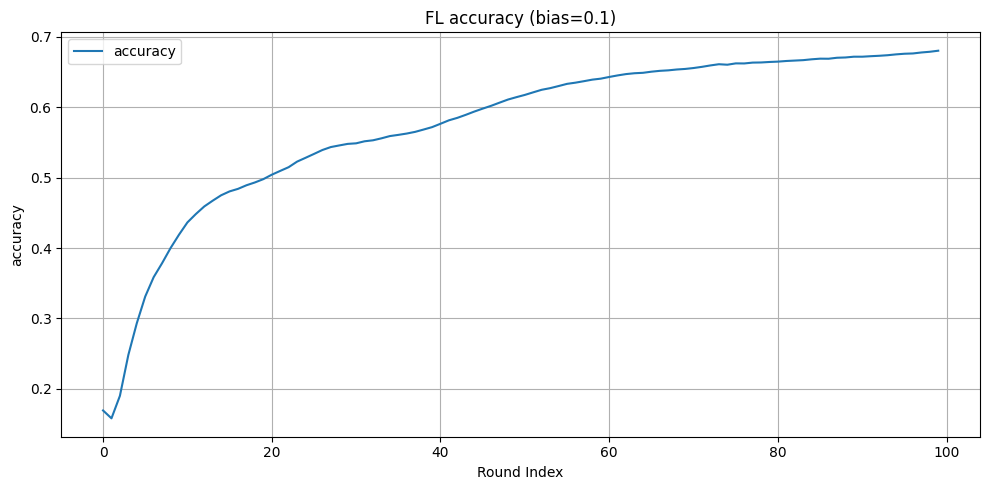

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.1

In [17]:
def lie_attack(all_updates, z):

    avg = torch.mean(all_updates, dim=0)

    std = torch.std(all_updates, dim=0)

    attacked_update = avg + z * std

    return attacked_update

In [27]:
accuracy_bias_0_1_lie_attack_redo = []
print(accuracy_bias_0_1_lie_attack_redo)

[]


In [28]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_lie_attack_redo.append(correct/total)

0 0.1008
1 0.1583
2 0.1853
3 0.191
4 0.2004
5 0.2164
6 0.2372
7 0.2538
8 0.2689
9 0.2827
10 0.2927
11 0.3068
12 0.3171
13 0.3274
14 0.337
15 0.345
16 0.3534
17 0.3615
18 0.3703
19 0.3768
20 0.385
21 0.3897
22 0.3954
23 0.4013
24 0.4072
25 0.4134
26 0.419
27 0.4246
28 0.4313
29 0.4351
30 0.4404
31 0.4436
32 0.4478
33 0.4512
34 0.4552
35 0.4598
36 0.464
37 0.4665
38 0.4695
39 0.474
40 0.4782
41 0.4832
42 0.4874
43 0.49
44 0.4939
45 0.4961
46 0.4984
47 0.5014
48 0.5041
49 0.5062
50 0.5091
51 0.5111
52 0.514
53 0.517
54 0.5212
55 0.5255
56 0.5279
57 0.5314
58 0.5344
59 0.5365
60 0.5387
61 0.5409
62 0.5431
63 0.5459
64 0.5485
65 0.5507
66 0.5534
67 0.5553
68 0.559
69 0.561
70 0.563
71 0.5664
72 0.5682
73 0.5712
74 0.5747
75 0.577
76 0.5815
77 0.585
78 0.5883
79 0.5907
80 0.5948
81 0.5974
82 0.6009
83 0.6038
84 0.6059
85 0.6084
86 0.6123
87 0.6157
88 0.6182
89 0.6215
90 0.6231
91 0.6267
92 0.6291
93 0.6315
94 0.6328
95 0.6356
96 0.6378
97 0.6393
98 0.6392
99 0.6407
CPU times: user 1min 18s, 

### LIE Attack, bias = 0.1. # of clients = 15

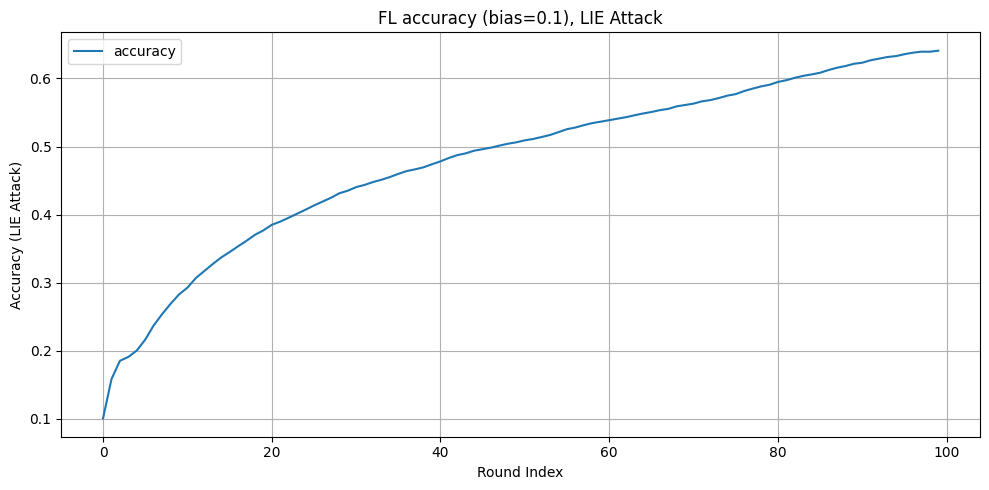

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1_lie_attack_redo, label='accuracy')
plt.title('FL accuracy (bias=0.1), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

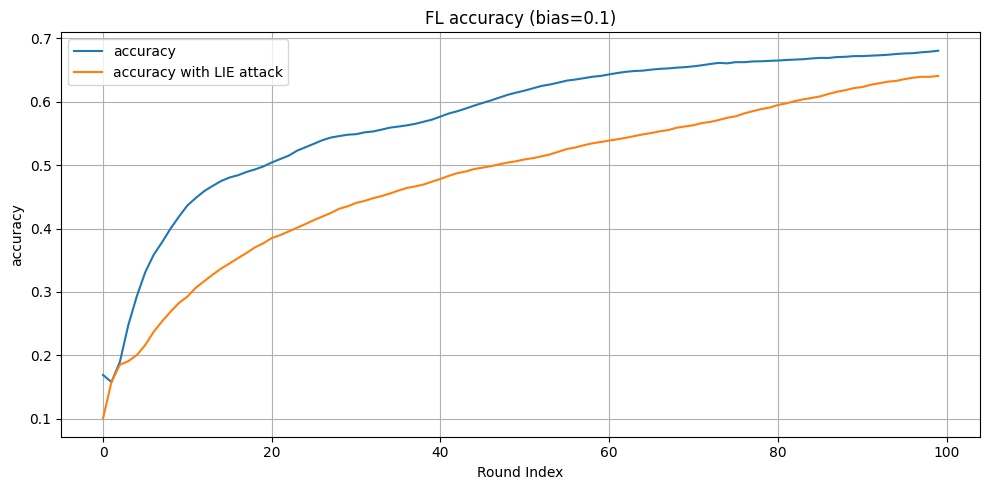

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy')
#plt.plot(accuracy_bias_0_1_lie_attack, label='accuracy with LIE attack')
plt.plot(accuracy_bias_0_1_lie_attack_redo, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.1

In [35]:
accuracy_bias_0_1_full_trim_attack = []
print(accuracy_bias_0_1_full_trim_attack)

[]


In [36]:
#Static 
#This is the attack.
def full_trim(v, f):
    '''
    Full-knowledge Trim attack. w.l.o.g., we assume the first f worker devices are compromised.
    v: the list of squeezed gradients
    f: the number of compromised worker devices
    '''
    # first compute the statistics
    vi_shape = v[0].unsqueeze(0).T.shape
    v_tran = v.T
#     v_tran = nd.concat(*v, dim=1)
    
    maximum_dim = torch.max(v_tran, dim=1)
    maximum_dim = maximum_dim[0].reshape(vi_shape)
    minimum_dim = torch.min(v_tran, dim=1)
    minimum_dim = minimum_dim[0].reshape(vi_shape)
    direction = torch.sign(torch.sum(v_tran, dim=-1, keepdims=True))
    directed_dim = (direction > 0) * minimum_dim + (direction < 0) * maximum_dim

    for i in range(f):
        # apply attack to compromised worker devices with randomness
        random_12 = 2
        tmp = directed_dim * ((direction * directed_dim > 0) / random_12 + (direction * directed_dim < 0) * random_12)
        tmp = tmp.squeeze()
        v[i] = tmp
    return v

In [37]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_full_trim_attack.append(correct/total)

0 0.0829
1 0.1378
2 0.1716
3 0.1728
4 0.1859
5 0.1873
6 0.1886
7 0.1948
8 0.2028
9 0.2132
10 0.2253
11 0.2403
12 0.2525
13 0.2643
14 0.2782
15 0.2899
16 0.3024
17 0.3166
18 0.3299
19 0.3421
20 0.3548
21 0.3687
22 0.3786
23 0.3876
24 0.3964
25 0.405
26 0.4137
27 0.4234
28 0.4322
29 0.4387
30 0.4449
31 0.4526
32 0.4592
33 0.4647
34 0.4683
35 0.4742
36 0.4781
37 0.4841
38 0.4879
39 0.4904
40 0.4943
41 0.4995
42 0.5055
43 0.5095
44 0.5139
45 0.5186
46 0.5231
47 0.5268
48 0.5324
49 0.5352
50 0.5387
51 0.5418
52 0.5451
53 0.5489
54 0.5507
55 0.5546
56 0.558
57 0.5619
58 0.5639
59 0.5659
60 0.5698
61 0.5722
62 0.5741
63 0.5776
64 0.5806
65 0.5827
66 0.5844
67 0.5868
68 0.589
69 0.5912
70 0.5936
71 0.5951
72 0.5959
73 0.598
74 0.6001
75 0.6018
76 0.6038
77 0.6059
78 0.6082
79 0.6097
80 0.6115
81 0.6138
82 0.6154
83 0.6168
84 0.6181
85 0.6193
86 0.62
87 0.6213
88 0.6225
89 0.6234
90 0.6247
91 0.6256
92 0.6264
93 0.6276
94 0.6287
95 0.6295
96 0.6302
97 0.6314
98 0.6325
99 0.6332
CPU times: user 

### full_trim attack, bias = 0.1, 15 clients

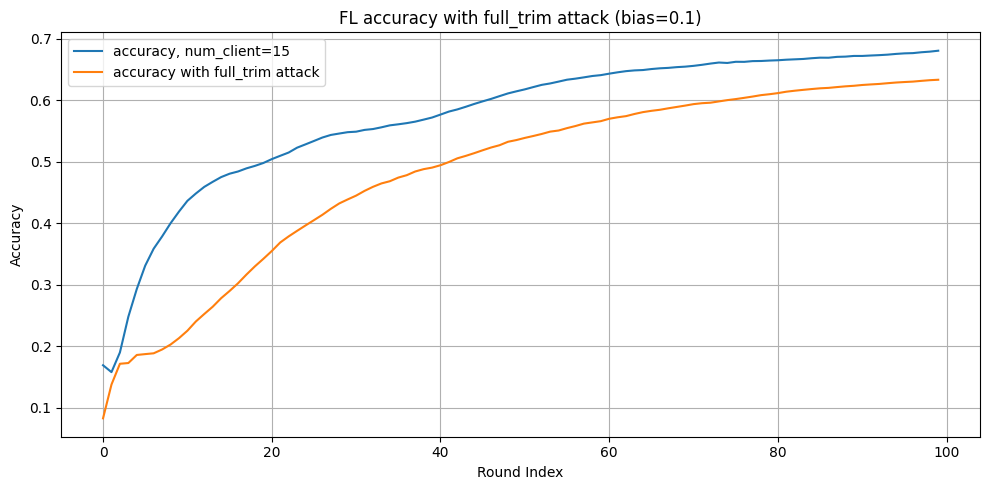

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracies_2

In [45]:
accuracy_bias_0_1_clients_10 = []

In [46]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_clients_10.append(correct/total)

0 0.0948
1 0.0963
2 0.1379
3 0.1657
4 0.1861
5 0.2048
6 0.2184
7 0.2543
8 0.2711
9 0.2756
10 0.2938
11 0.3152
12 0.3389
13 0.36
14 0.3808
15 0.4032
16 0.422
17 0.4374
18 0.451
19 0.4636
20 0.4763
21 0.4883
22 0.497
23 0.5055
24 0.5139
25 0.5207
26 0.5288
27 0.5371
28 0.5437
29 0.5488
30 0.5535
31 0.5572
32 0.5604
33 0.5625
34 0.564
35 0.5672
36 0.5693
37 0.569
38 0.5703
39 0.5707
40 0.571
41 0.5724
42 0.5729
43 0.5727
44 0.5738
45 0.5748
46 0.575
47 0.5751
48 0.5751
49 0.5755
50 0.5763
51 0.5773
52 0.5787
53 0.58
54 0.5823
55 0.5833
56 0.5838
57 0.5847
58 0.586
59 0.5876
60 0.59
61 0.5917
62 0.5943
63 0.5983
64 0.6004
65 0.6039
66 0.6067
67 0.609
68 0.6123
69 0.6158
70 0.6185
71 0.6222
72 0.6237
73 0.6248
74 0.626
75 0.6266
76 0.6281
77 0.6299
78 0.6327
79 0.6335
80 0.6347
81 0.6359
82 0.6366
83 0.6389
84 0.6404
85 0.6411
86 0.6428
87 0.6439
88 0.6448
89 0.6457
90 0.6469
91 0.6472
92 0.6485
93 0.6495
94 0.6496
95 0.6509
96 0.6518
97 0.6523
98 0.6525
99 0.6532
CPU times: user 1min, sys:

### 3 graphs for full_trim, bias = 0.1

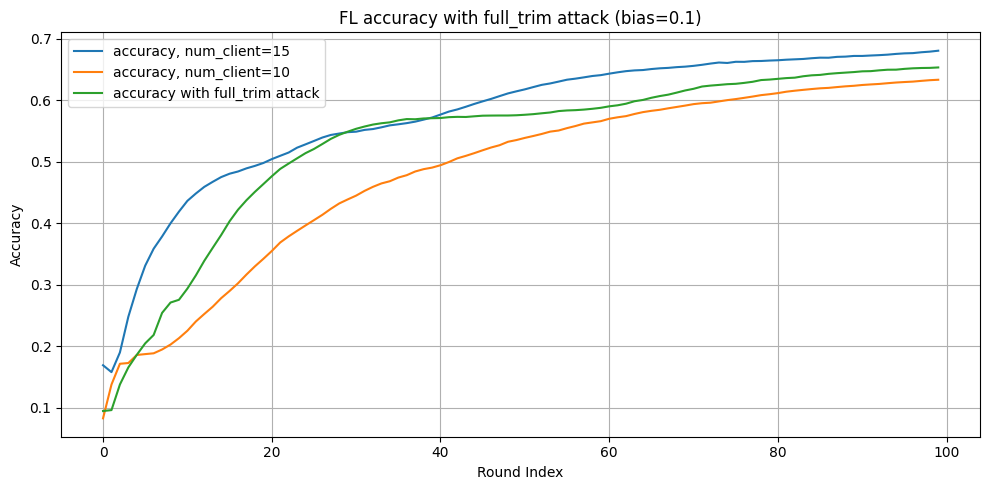

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_1_clients_10, label='accuracy with full_trim attack')


plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [48]:
#This is the defense. It performs dimension-wise filtering of the model updates i.e., it chops off the outliers.
def tr_mean(all_updates, n_attackers):
    sorted_updates = torch.sort(all_updates, 0)[0]
    out = torch.mean(sorted_updates[n_attackers:-n_attackers], 0) if n_attackers else torch.mean(sorted_updates,0)
    return out

In [49]:
accuracy_bias_0_1_full_trim_defense = []

In [50]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_full_trim_defense.append(correct/total)

0 0.0996
1 0.1424
2 0.192
3 0.2145
4 0.23
5 0.2471
6 0.2692
7 0.2889
8 0.3091
9 0.3277
10 0.3417
11 0.3555
12 0.3669
13 0.3752
14 0.3816
15 0.3889
16 0.3929
17 0.3965
18 0.3996
19 0.4016
20 0.4012
21 0.4046
22 0.4077
23 0.4129
24 0.4166
25 0.4205
26 0.4257
27 0.4315
28 0.4361
29 0.4409
30 0.4469
31 0.4504
32 0.4538
33 0.4575
34 0.462
35 0.466
36 0.4695
37 0.4743
38 0.4786
39 0.4821
40 0.4856
41 0.489
42 0.4906
43 0.495
44 0.4979
45 0.5006
46 0.5034
47 0.5065
48 0.511
49 0.5156
50 0.5198
51 0.5235
52 0.5289
53 0.5326
54 0.5368
55 0.5415
56 0.5452
57 0.5487
58 0.553
59 0.5579
60 0.5614
61 0.5663
62 0.5694
63 0.5739
64 0.5784
65 0.5809
66 0.5838
67 0.5881
68 0.5892
69 0.5918
70 0.5945
71 0.5978
72 0.6001
73 0.6012
74 0.6041
75 0.6057
76 0.608
77 0.609
78 0.6113
79 0.613
80 0.6147
81 0.6169
82 0.6184
83 0.6206
84 0.623
85 0.6247
86 0.6259
87 0.6273
88 0.6288
89 0.6306
90 0.6318
91 0.6331
92 0.6338
93 0.635
94 0.6355
95 0.6371
96 0.6394
97 0.6415
98 0.6418
99 0.6437
CPU times: user 1min 17s

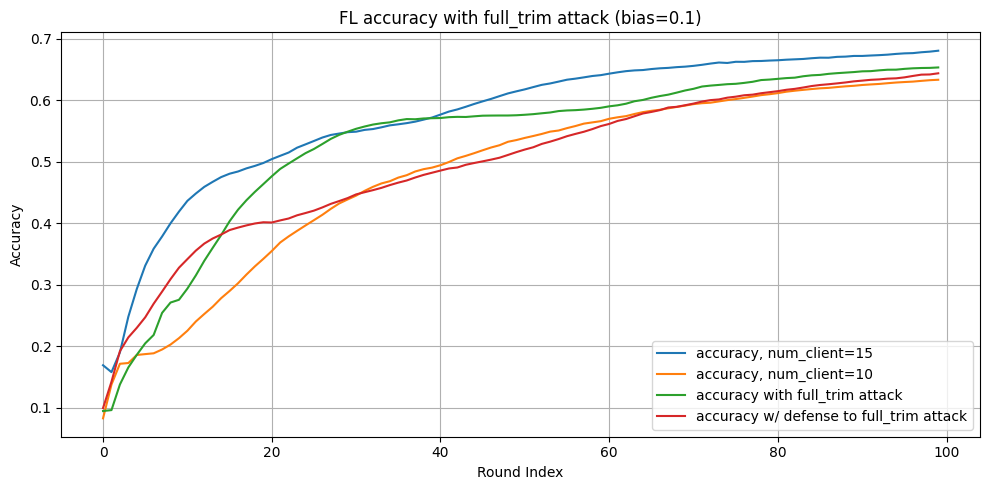

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_1_clients_10, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_1_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# bias = 0.5, # of clients = 15
# ===============================

In [55]:
bias = 0.5
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [56]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_170884/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [57]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [58]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [59]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_5

In [60]:
accuracy_bias_0_5 = []
print(accuracy_bias_0_5)

[]


In [61]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5.append(correct/total)

0 0.0838
1 0.0942
2 0.1474
3 0.2005
4 0.237
5 0.2591
6 0.2739
7 0.2872
8 0.2971
9 0.3065
10 0.3149
11 0.3243
12 0.3355
13 0.3452
14 0.3538
15 0.3634
16 0.3736
17 0.3826
18 0.3917
19 0.3989
20 0.4067
21 0.4152
22 0.4237
23 0.4296
24 0.436
25 0.4434
26 0.4507
27 0.4607
28 0.4688
29 0.4774
30 0.4858
31 0.4979
32 0.5087
33 0.5179
34 0.5259
35 0.5354
36 0.5447
37 0.552
38 0.5599
39 0.5667
40 0.5714
41 0.5771
42 0.5832
43 0.5879
44 0.5911
45 0.5965
46 0.5998
47 0.6029
48 0.6064
49 0.6101
50 0.6129
51 0.6165
52 0.6206
53 0.6225
54 0.6248
55 0.629
56 0.6302
57 0.6331
58 0.6354
59 0.637
60 0.6382
61 0.6386
62 0.6405
63 0.6415
64 0.6431
65 0.6432
66 0.6445
67 0.6449
68 0.6464
69 0.6475
70 0.6478
71 0.6486
72 0.6495
73 0.6505
74 0.6516
75 0.6524
76 0.653
77 0.6541
78 0.6545
79 0.6551
80 0.6564
81 0.6576
82 0.6588
83 0.6601
84 0.6611
85 0.6617
86 0.6626
87 0.6634
88 0.6638
89 0.6637
90 0.6647
91 0.6655
92 0.6665
93 0.6675
94 0.6684
95 0.6688
96 0.67
97 0.6706
98 0.671
99 0.6725
CPU times: user 1mi

### Displaying results, bias = 0.5. # of clients = 15

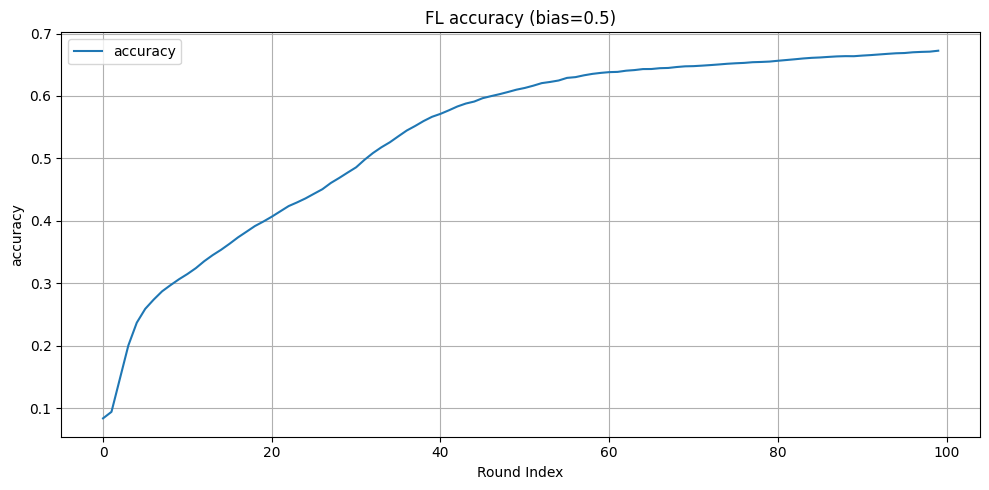

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.5

In [63]:
accuracy_bias_0_5_lie_attack = []
print(accuracy_bias_0_5_lie_attack)

[]


### saving to accuracy_bias_0_5_lie_attack

In [64]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_lie_attack.append(correct/total)

0 0.1391
1 0.1502
2 0.1231
3 0.1197
4 0.1127
5 0.1046
6 0.1104
7 0.1117
8 0.1078
9 0.1057
10 0.1053
11 0.111
12 0.1191
13 0.1255
14 0.1309
15 0.1338
16 0.1343
17 0.1336
18 0.1344
19 0.1334
20 0.1322
21 0.1315
22 0.1305
23 0.1292
24 0.1284
25 0.1283
26 0.1281
27 0.1281
28 0.1286
29 0.1287
30 0.129
31 0.1291
32 0.1292
33 0.1293
34 0.1289
35 0.129
36 0.129
37 0.1291
38 0.1295
39 0.1298
40 0.1299
41 0.1296
42 0.1296
43 0.1295
44 0.1296
45 0.1301
46 0.1302
47 0.1308
48 0.1311
49 0.1318
50 0.132
51 0.1321
52 0.1324
53 0.1326
54 0.133
55 0.1333
56 0.1335
57 0.134
58 0.1342
59 0.1341
60 0.1346
61 0.1348
62 0.1349
63 0.1353
64 0.1356
65 0.136
66 0.1365
67 0.1362
68 0.1363
69 0.1366
70 0.1367
71 0.137
72 0.1372
73 0.1379
74 0.1381
75 0.1379
76 0.1382
77 0.1385
78 0.1385
79 0.1388
80 0.1389
81 0.1395
82 0.1395
83 0.1394
84 0.1396
85 0.1399
86 0.1401
87 0.1406
88 0.1405
89 0.141
90 0.1412
91 0.1412
92 0.1414
93 0.1417
94 0.1417
95 0.1419
96 0.142
97 0.1426
98 0.1428
99 0.1432
CPU times: user 1min 

### LIE Attack, bias = 0.5. # of clients = 15

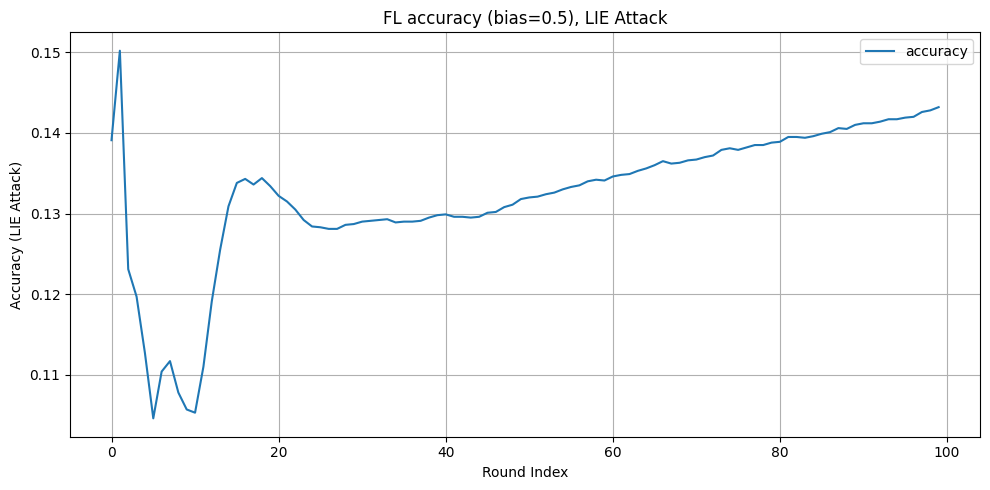

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.5), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

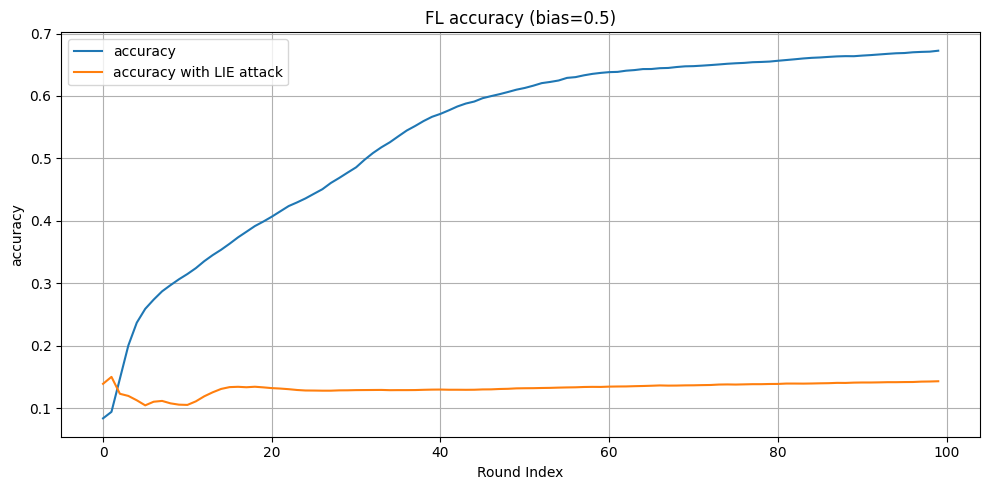

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.plot(accuracy_bias_0_5_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.5

In [67]:
accuracy_bias_0_5_full_trim_attack = []
print(accuracy_bias_0_5_full_trim_attack)

[]


In [68]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_full_trim_attack.append(correct/total)

0 0.1356
1 0.0995
2 0.1472
3 0.1588
4 0.171
5 0.176
6 0.18
7 0.1831
8 0.1856
9 0.1868
10 0.1886
11 0.1901
12 0.1912
13 0.1931
14 0.194
15 0.1963
16 0.1977
17 0.199
18 0.2004
19 0.2018
20 0.2034
21 0.2041
22 0.2052
23 0.2072
24 0.2074
25 0.2076
26 0.2087
27 0.209
28 0.2093
29 0.2098
30 0.21
31 0.2104
32 0.2105
33 0.211
34 0.2116
35 0.2116
36 0.212
37 0.2122
38 0.2125
39 0.2129
40 0.2128
41 0.2129
42 0.2132
43 0.2136
44 0.2137
45 0.2141
46 0.2148
47 0.2149
48 0.216
49 0.2183
50 0.2193
51 0.2207
52 0.222
53 0.2234
54 0.2253
55 0.2272
56 0.2308
57 0.235
58 0.2376
59 0.2396
60 0.2438
61 0.2468
62 0.2503
63 0.2526
64 0.2565
65 0.2585
66 0.261
67 0.2631
68 0.2683
69 0.2707
70 0.2737
71 0.2751
72 0.2776
73 0.2791
74 0.2812
75 0.2832
76 0.2853
77 0.2869
78 0.2885
79 0.2894
80 0.2913
81 0.2939
82 0.295
83 0.2965
84 0.2977
85 0.2991
86 0.3001
87 0.301
88 0.3026
89 0.3034
90 0.3041
91 0.3047
92 0.3066
93 0.3063
94 0.3084
95 0.3082
96 0.3099
97 0.311
98 0.3116
99 0.3122
CPU times: user 1min 17s, sy

### full_trim attack, bias = 0.5, 15 clients

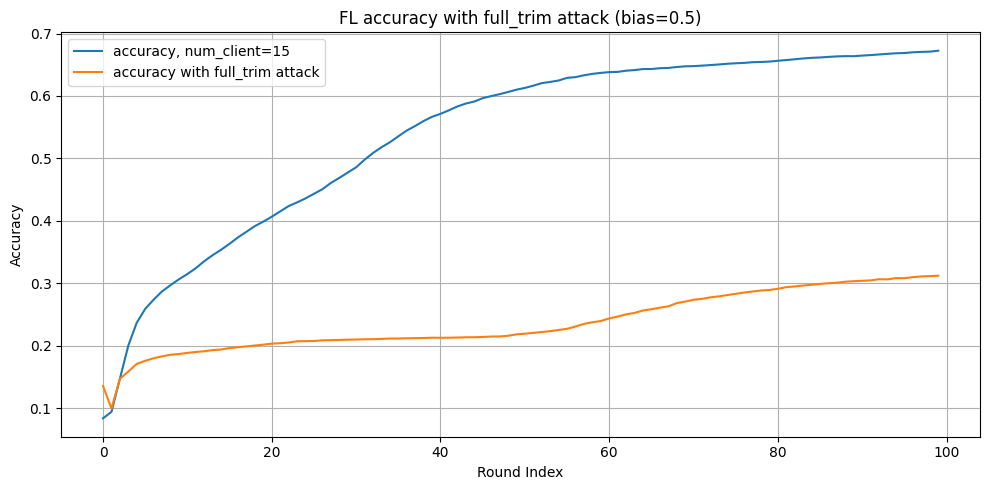

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_5_clients_10

In [79]:
accuracy_bias_0_5_clients_10 = []
print(accuracy_bias_0_5_clients_10)

[]


In [80]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_clients_10.append(correct/total)

0 0.0965
1 0.184
2 0.1857
3 0.1616
4 0.161
5 0.1685
6 0.1797
7 0.1925
8 0.2051
9 0.2199
10 0.234
11 0.2482
12 0.2617
13 0.2737
14 0.2882
15 0.2992
16 0.313
17 0.3263
18 0.3369
19 0.3452
20 0.3545
21 0.3594
22 0.3647
23 0.3687
24 0.3739
25 0.3794
26 0.3852
27 0.3896
28 0.3934
29 0.3976
30 0.4031
31 0.4082
32 0.4134
33 0.4185
34 0.422
35 0.4268
36 0.4298
37 0.4344
38 0.4386
39 0.4422
40 0.4454
41 0.4497
42 0.4543
43 0.4588
44 0.4645
45 0.4703
46 0.4754
47 0.4813
48 0.4868
49 0.4924
50 0.4988
51 0.5048
52 0.5102
53 0.5144
54 0.5179
55 0.5233
56 0.5276
57 0.5316
58 0.5356
59 0.5406
60 0.5458
61 0.5501
62 0.5541
63 0.5568
64 0.5595
65 0.5631
66 0.5665
67 0.5697
68 0.5724
69 0.5747
70 0.5776
71 0.58
72 0.5823
73 0.5835
74 0.5854
75 0.5865
76 0.5883
77 0.5904
78 0.5928
79 0.5936
80 0.595
81 0.5965
82 0.5976
83 0.5992
84 0.6013
85 0.6027
86 0.6046
87 0.6058
88 0.6066
89 0.6074
90 0.6082
91 0.6095
92 0.6104
93 0.6112
94 0.6121
95 0.613
96 0.6137
97 0.6147
98 0.6158
99 0.6167
CPU times: user 58.

### 3 graphs for full_trim, bias = 0.5

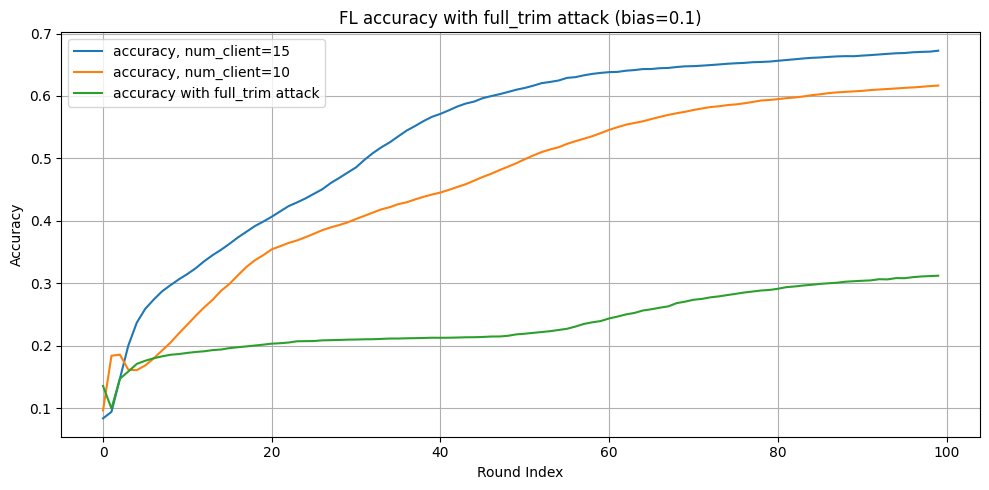

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [73]:
accuracy_bias_0_5_full_trim_defense = []
print(accuracy_bias_0_5_full_trim_defense)

[]


In [74]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_full_trim_defense.append(correct/total)

0 0.1037
1 0.0768
2 0.0824
3 0.0862
4 0.0897
5 0.0833
6 0.0831
7 0.0886
8 0.0961
9 0.1026
10 0.1098
11 0.117
12 0.1251
13 0.1318
14 0.1378
15 0.1433
16 0.1482
17 0.1512
18 0.1547
19 0.1574
20 0.1593
21 0.1609
22 0.1622
23 0.1631
24 0.1644
25 0.1657
26 0.167
27 0.1681
28 0.1693
29 0.1697
30 0.1702
31 0.171
32 0.1716
33 0.1727
34 0.1736
35 0.1743
36 0.1745
37 0.1748
38 0.1755
39 0.1763
40 0.1781
41 0.1813
42 0.1846
43 0.1889
44 0.1915
45 0.1953
46 0.1979
47 0.2011
48 0.2042
49 0.208
50 0.2116
51 0.2165
52 0.2203
53 0.2238
54 0.2271
55 0.2301
56 0.2334
57 0.2359
58 0.2388
59 0.2411
60 0.2439
61 0.2475
62 0.25
63 0.2517
64 0.2529
65 0.2544
66 0.2556
67 0.2567
68 0.2574
69 0.2579
70 0.2585
71 0.2597
72 0.2611
73 0.262
74 0.2641
75 0.266
76 0.2694
77 0.273
78 0.277
79 0.2817
80 0.2846
81 0.2886
82 0.2921
83 0.2959
84 0.2995
85 0.3021
86 0.3045
87 0.3076
88 0.3104
89 0.312
90 0.3143
91 0.3163
92 0.3181
93 0.3197
94 0.3211
95 0.3225
96 0.324
97 0.3252
98 0.3272
99 0.3287
CPU times: user 1min 1

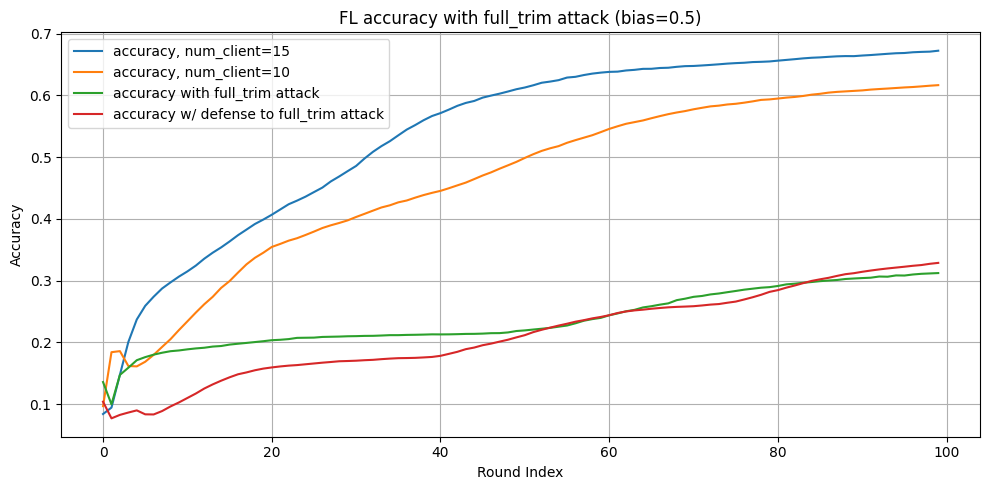

In [82]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_5_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# bias = 0.9, # of clients = 15
# ===============================

In [153]:
bias = 0.9
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [154]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_170884/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [155]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [156]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [157]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_9

In [158]:
accuracy_bias_0_9 = []
print(accuracy_bias_0_9)

[]


In [159]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9.append(correct/total)

0 0.1711
1 0.2286
2 0.2341
3 0.2589
4 0.2826
5 0.3027
6 0.3203
7 0.3291
8 0.3393
9 0.349
10 0.3601
11 0.368
12 0.3748
13 0.3812
14 0.3905
15 0.3973
16 0.4062
17 0.4164
18 0.4264
19 0.4335
20 0.4421
21 0.4515
22 0.4588
23 0.467
24 0.4761
25 0.4814
26 0.489
27 0.4968
28 0.5038
29 0.5093
30 0.5161
31 0.5224
32 0.5284
33 0.535
34 0.5401
35 0.5436
36 0.5488
37 0.5521
38 0.5562
39 0.5595
40 0.5629
41 0.567
42 0.5707
43 0.576
44 0.5781
45 0.5803
46 0.5839
47 0.5879
48 0.5913
49 0.594
50 0.5985
51 0.6037
52 0.6067
53 0.6109
54 0.6148
55 0.6192
56 0.6234
57 0.6256
58 0.6283
59 0.6305
60 0.6332
61 0.6355
62 0.6365
63 0.6381
64 0.6397
65 0.6417
66 0.643
67 0.6441
68 0.6455
69 0.6461
70 0.6476
71 0.6484
72 0.6493
73 0.6502
74 0.6506
75 0.6525
76 0.6531
77 0.654
78 0.6548
79 0.6551
80 0.6558
81 0.657
82 0.6581
83 0.6582
84 0.6591
85 0.66
86 0.6604
87 0.6613
88 0.6615
89 0.662
90 0.663
91 0.6635
92 0.6646
93 0.6651
94 0.6656
95 0.6667
96 0.667
97 0.6673
98 0.6671
99 0.6677
CPU times: user 1min 19s, 

### Displaying results, bias = 0.9. # of clients = 15

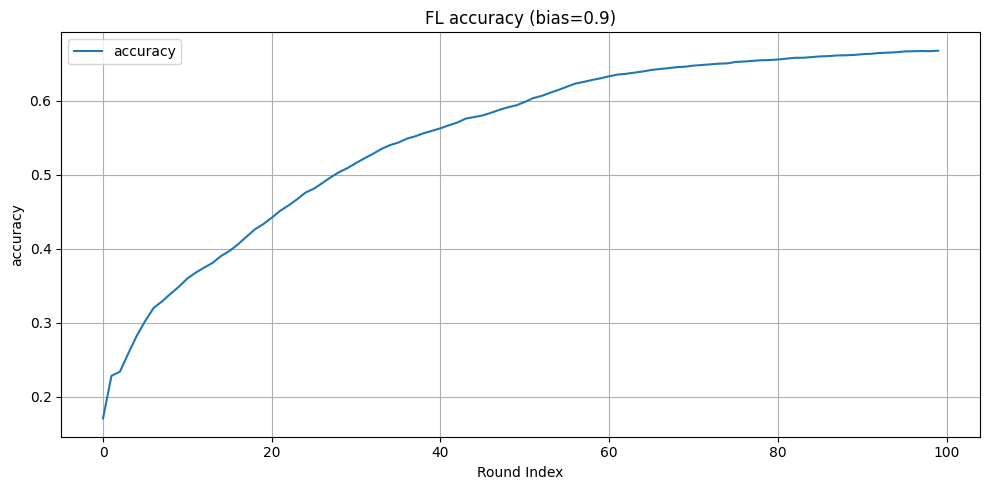

In [160]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.9

In [161]:
accuracy_bias_0_9_lie_attack = []
print(accuracy_bias_0_9_lie_attack)

[]


### saving to accuracy_bias_0_9_lie_attack

In [162]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_lie_attack.append(correct/total)

0 0.1
1 0.0999
2 0.1006
3 0.104
4 0.1091
5 0.1092
6 0.1119
7 0.1092
8 0.109
9 0.1081
10 0.1076
11 0.1076
12 0.1072
13 0.1069
14 0.1063
15 0.1065
16 0.106
17 0.106
18 0.105
19 0.1051
20 0.1052
21 0.105
22 0.1047
23 0.1048
24 0.1048
25 0.1041
26 0.1041
27 0.1037
28 0.1032
29 0.1029
30 0.1024
31 0.1025
32 0.1024
33 0.1022
34 0.1021
35 0.1021
36 0.1018
37 0.1016
38 0.1018
39 0.1018
40 0.1016
41 0.1016
42 0.1016
43 0.1016
44 0.1016
45 0.1016
46 0.1014
47 0.1014
48 0.1012
49 0.1011
50 0.101
51 0.101
52 0.101
53 0.101
54 0.101
55 0.1008
56 0.1008
57 0.1006
58 0.1005
59 0.1006
60 0.1007
61 0.1007
62 0.1006
63 0.1004
64 0.1002
65 0.1002
66 0.1002
67 0.1002
68 0.1002
69 0.1002
70 0.1002
71 0.1002
72 0.1001
73 0.1001
74 0.1001
75 0.1001
76 0.1001
77 0.1
78 0.1
79 0.1
80 0.1
81 0.1
82 0.1
83 0.1
84 0.0999
85 0.0999
86 0.0999
87 0.0999
88 0.0999
89 0.0999
90 0.0998
91 0.0998
92 0.0998
93 0.0998
94 0.0998
95 0.0998
96 0.0998
97 0.0998
98 0.0998
99 0.0998
CPU times: user 1min 18s, sys: 4.63 s, total:

### LIE Attack, bias = 0.9. # of clients = 15

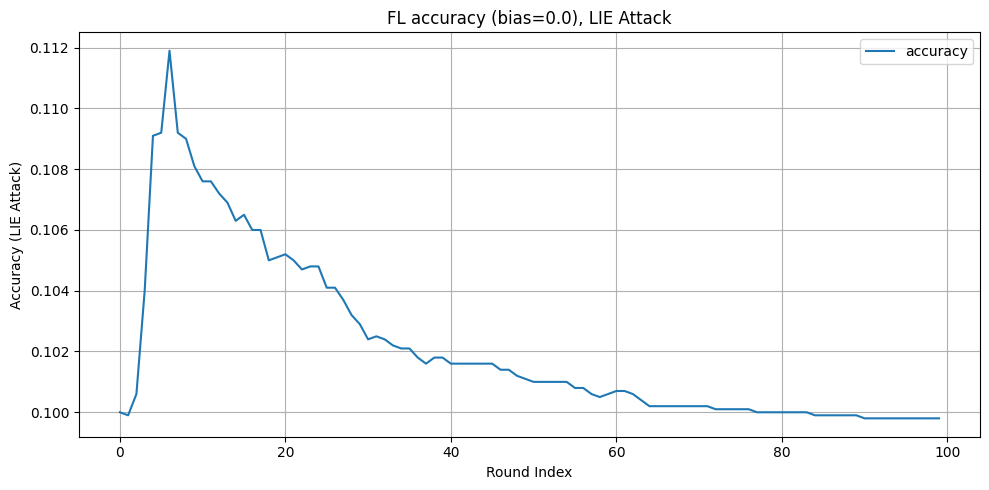

In [163]:
plt.figure(figsize=(10, 5))
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.0), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

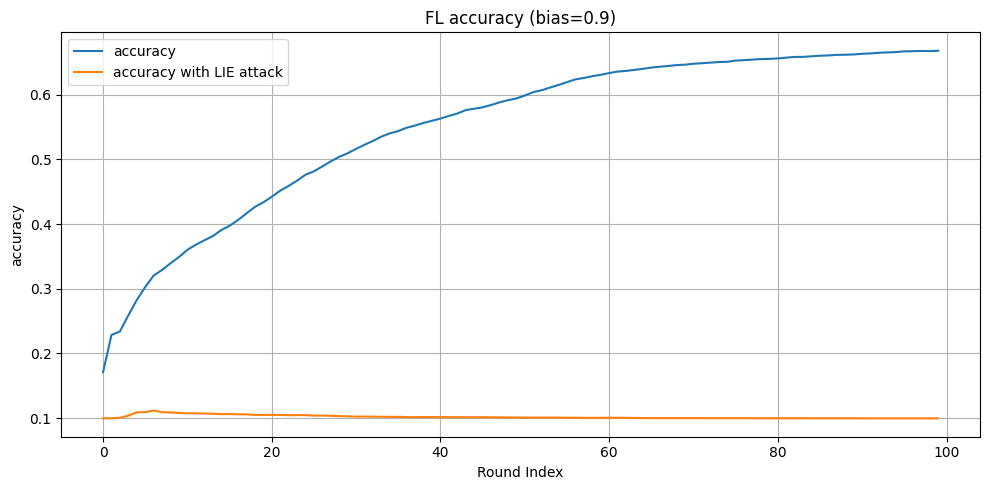

In [164]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy')
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.9

In [165]:
accuracy_bias_0_9_full_trim_attack = []
print(accuracy_bias_0_9_full_trim_attack)

[]


In [166]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_full_trim_attack.append(correct/total)

0 0.095
1 0.0732
2 0.0832
3 0.0744
4 0.0722
5 0.075
6 0.0728
7 0.0738
8 0.0749
9 0.0802
10 0.0825
11 0.0859
12 0.0887
13 0.0894
14 0.0888
15 0.0906
16 0.091
17 0.0947
18 0.1027
19 0.1066
20 0.1147
21 0.1227
22 0.132
23 0.1396
24 0.1493
25 0.1622
26 0.1768
27 0.1884
28 0.1995
29 0.2106
30 0.2183
31 0.2308
32 0.2345
33 0.2488
34 0.2334
35 0.2296
36 0.1069
37 0.1931
38 0.1
39 0.157
40 0.1445
41 0.1372
42 0.2237
43 0.1905
44 0.2149
45 0.1941
46 0.1063
47 0.1017
48 0.1046
49 0.1812
50 0.2172
51 0.227
52 0.2233
53 0.2245
54 0.1947
55 0.1327
56 0.0979
57 0.1311
58 0.1575
59 0.1678
60 0.2235
61 0.238
62 0.2216
63 0.2388
64 0.222
65 0.2067
66 0.2392
67 0.2398
68 0.2477
69 0.2236
70 0.2366
71 0.2234
72 0.224
73 0.293
74 0.2819
75 0.2676
76 0.2548
77 0.2404
78 0.2605
79 0.1767
80 0.201
81 0.2598
82 0.3265
83 0.2811
84 0.285
85 0.2822
86 0.2857
87 0.2768
88 0.2746
89 0.2529
90 0.2668
91 0.2448
92 0.2649
93 0.172
94 0.2936
95 0.2734
96 0.285
97 0.2797
98 0.2869
99 0.2819
CPU times: user 1min 18s, s

### full_trim attack, bias = 0.9, 15 clients

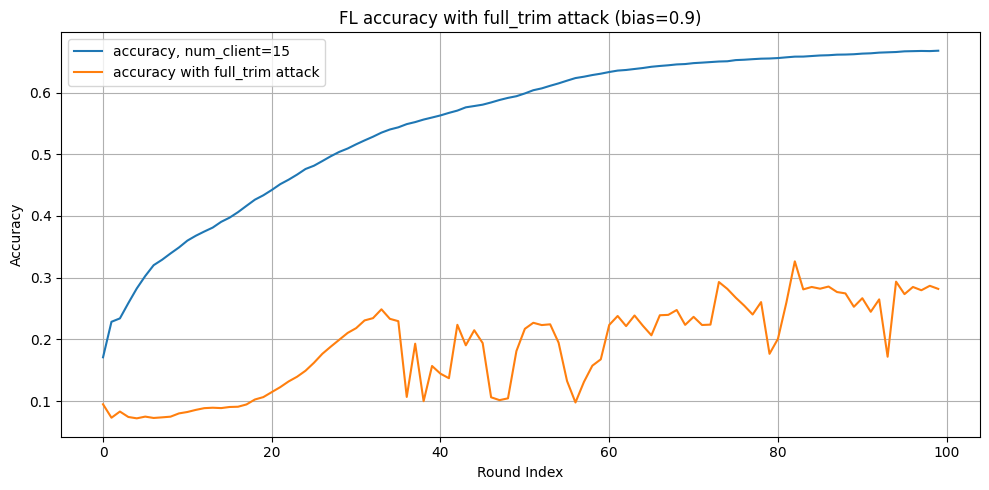

In [167]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_9_clients_10

In [168]:
accuracy_bias_0_9_clients_10 = []
print(accuracy_bias_0_9_clients_10)

[]


In [169]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_clients_10.append(correct/total)

0 0.1407
1 0.1423
2 0.1472
3 0.1522
4 0.1575
5 0.1617
6 0.1642
7 0.1688
8 0.1744
9 0.1852
10 0.1966
11 0.2064
12 0.2134
13 0.2192
14 0.2241
15 0.2286
16 0.2319
17 0.2351
18 0.2386
19 0.2408
20 0.2432
21 0.2456
22 0.2498
23 0.2579
24 0.2675
25 0.2783
26 0.2895
27 0.3035
28 0.3172
29 0.3308
30 0.3441
31 0.3563
32 0.3686
33 0.381
34 0.3902
35 0.4008
36 0.411
37 0.4192
38 0.4256
39 0.4335
40 0.4402
41 0.4459
42 0.4513
43 0.4571
44 0.4614
45 0.4657
46 0.4703
47 0.475
48 0.4798
49 0.4838
50 0.4883
51 0.4925
52 0.4967
53 0.5006
54 0.5036
55 0.5074
56 0.5119
57 0.5163
58 0.519
59 0.5223
60 0.5256
61 0.5284
62 0.5325
63 0.5363
64 0.5401
65 0.5442
66 0.5483
67 0.5523
68 0.5555
69 0.5584
70 0.5622
71 0.5652
72 0.569
73 0.5732
74 0.5769
75 0.579
76 0.581
77 0.5846
78 0.5877
79 0.5899
80 0.5925
81 0.5946
82 0.5963
83 0.5983
84 0.5997
85 0.6015
86 0.6037
87 0.6064
88 0.6083
89 0.6095
90 0.6108
91 0.6128
92 0.6152
93 0.6163
94 0.6185
95 0.6199
96 0.6218
97 0.6228
98 0.6236
99 0.6257
CPU times: user 1

### 3 graphs for full_trim, bias = 0.9

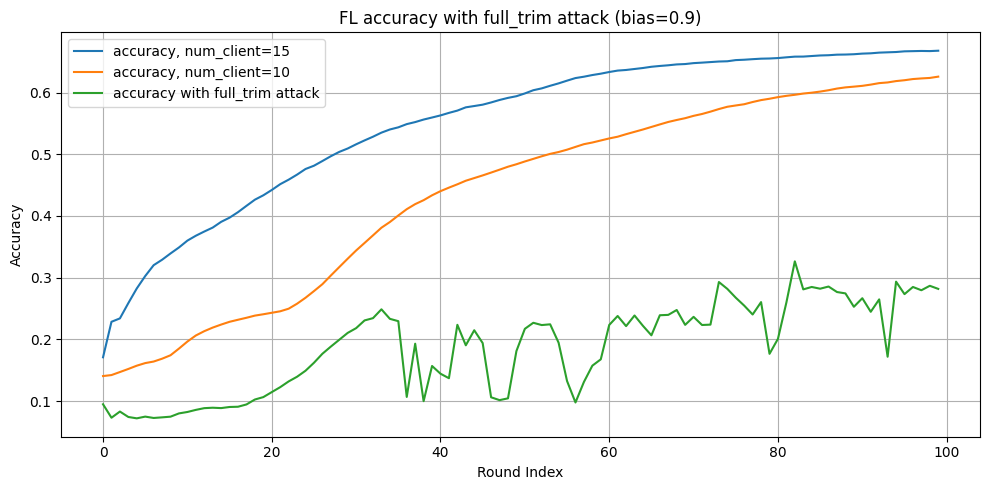

In [170]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [171]:
accuracy_bias_0_9_full_trim_defense = []
print(accuracy_bias_0_9_full_trim_defense)

[]


In [172]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_full_trim_defense.append(correct/total)

0 0.0999
1 0.0976
2 0.0974
3 0.0979
4 0.1002
5 0.1014
6 0.1039
7 0.1051
8 0.1056
9 0.106
10 0.1071
11 0.1069
12 0.1045
13 0.1031
14 0.1008
15 0.1001
16 0.0972
17 0.0965
18 0.0974
19 0.099
20 0.1048
21 0.1126
22 0.1119
23 0.1139
24 0.1138
25 0.1219
26 0.1305
27 0.1345
28 0.1361
29 0.137
30 0.1393
31 0.1401
32 0.141
33 0.1412
34 0.1427
35 0.1418
36 0.1431
37 0.1437
38 0.1464
39 0.1429
40 0.153
41 0.1249
42 0.1735
43 0.1002
44 0.0997
45 0.1006
46 0.0982
47 0.0771
48 0.1055
49 0.1014
50 0.1016
51 0.1172
52 0.1199
53 0.179
54 0.1025
55 0.1055
56 0.1361
57 0.1786
58 0.1704
59 0.1876
60 0.1292
61 0.0992
62 0.094
63 0.0993
64 0.1817
65 0.1838
66 0.1052
67 0.1132
68 0.1001
69 0.1068
70 0.1277
71 0.1486
72 0.0971
73 0.0956
74 0.1008
75 0.1378
76 0.1962
77 0.1188
78 0.1088
79 0.1227
80 0.1827
81 0.1214
82 0.1689
83 0.1358
84 0.1926
85 0.1005
86 0.1703
87 0.1183
88 0.1211
89 0.1779
90 0.1069
91 0.185
92 0.1
93 0.1451
94 0.1955
95 0.2158
96 0.1845
97 0.2276
98 0.1116
99 0.1057
CPU times: user 1min 

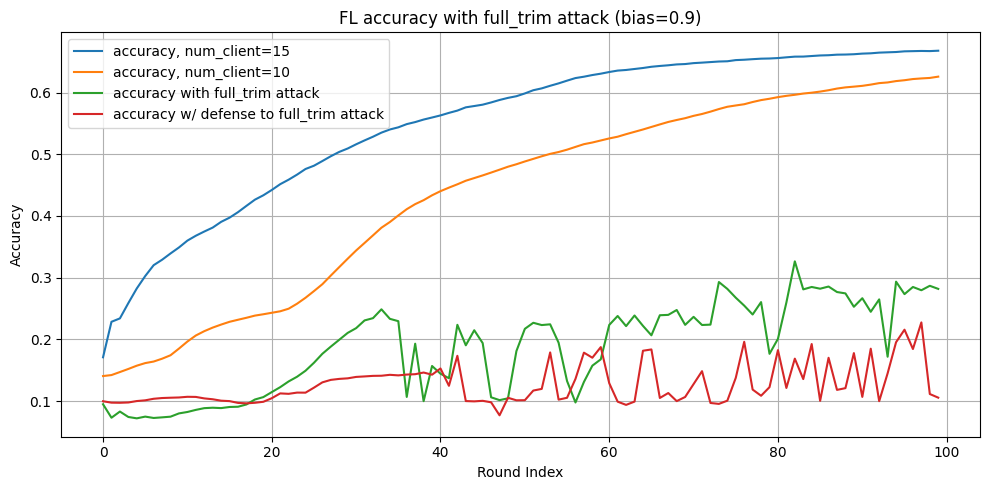

In [174]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_9_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graphing all

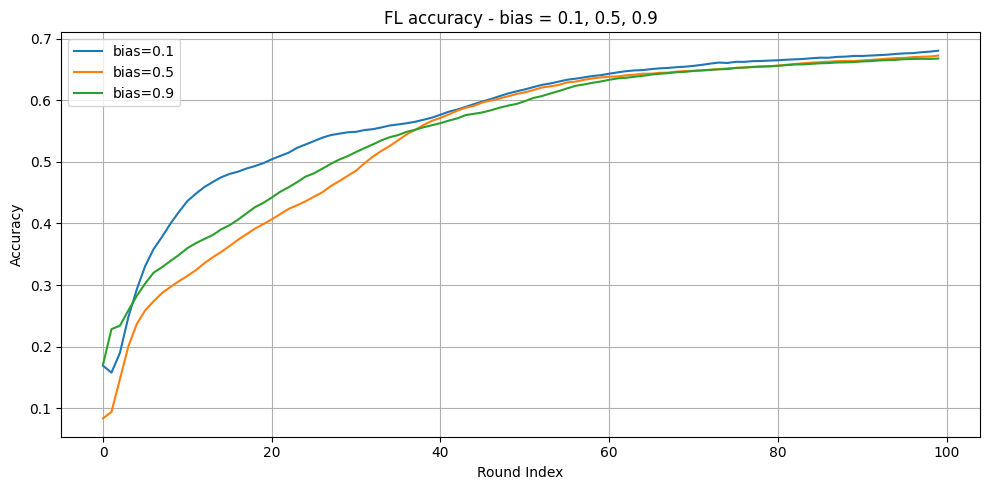

In [175]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label="bias=0.1")
plt.plot(accuracy_bias_0_5, label="bias=0.5")
plt.plot(accuracy_bias_0_9, label="bias=0.9")
plt.title('FL accuracy - bias = 0.1, 0.5, 0.9')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()